In [1]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl

# Add the subdir to sys.path for our created scripts
# sys.path.append('/home/jovyan/home/research_work/useful_py_scripts/')
# sys.path.append('/home/jovyan/home/research_work/making_figures/paper_figures/')
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')

# Now you can import the module
import useful_fncs
import figure_utils
import utils_from_others

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

In [2]:
# let's first look at the NSNS_output

# the average_SF_mass_needed is Average_SF_mass_needed =  10892909.034667056

pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N1e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixture_weights = mixture_weights_all[DCO_mask_NSNS]

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes = lifetimes_all[DCO_mask_NSNS]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times = col_times_all[DCO_mask_NSNS]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times = lifetimes + col_times

In [3]:
# let's plot the rate of the systems that merge within a hubble time

hubble_time = 13.9e3
condition_mergers = delay_times < hubble_time
mergers = np.sum(condition_mergers)

# mixture_weights_merged = mixture_weights[condition_mergers]

rates_DCO = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked = rates_DCO[condition_mergers]

redshifts = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]


# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1 = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2 = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2[condition_mergers]

NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)
NSNS_rate = np.sum(rates_DCO_masked[NSNS_systems_bool], axis=0)

In [4]:
# let's now do this for the WDWD systems 

HeWD_bool,COWD_bool,ONeWD_bool,HeCOWD_bool,HeONeWD_bool,COHeWD_bool,COONeWD_bool,ONeHeWD_bool,ONeCOWD_bool = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged, stellar_types_2_merged)
carbon_oxygen_bool = np.logical_or(ONeCOWD_bool,np.logical_or(COONeWD_bool,np.logical_or(COHeWD_bool,np.logical_or(COWD_bool,HeCOWD_bool))))

cowd_rate = np.sum(rates_DCO_masked[carbon_oxygen_bool], axis=0)


In [5]:
# selecting for NSNS
mass_1_all = DCOs_NSNS['Mass(1)'][()]
mass_1 = mass_1_all[DCO_mask_NSNS]
mass_1_merged = mass_1[condition_mergers]

mass_2_all = DCOs_NSNS['Mass(2)'][()]
mass_2 = mass_2_all[DCO_mask_NSNS]
mass_2_merged = mass_2[condition_mergers]

Text(0.5, 0, 'Mass(1)')

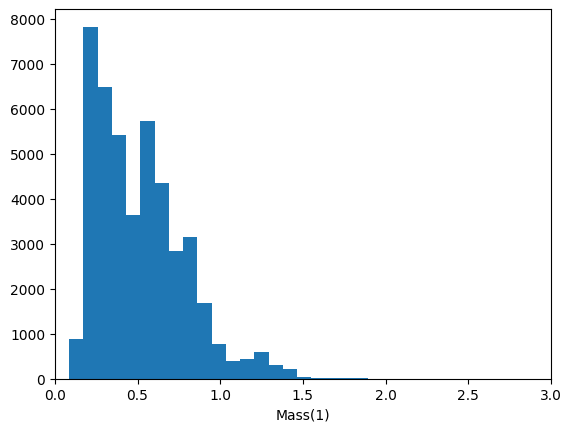

In [6]:
plt.hist(mass_1_merged, bins = np.linspace(0, 2.5, 30))
plt.xlim(0,3)
plt.xlabel("Mass(1)")

Text(0.5, 0, 'Mass(2)')

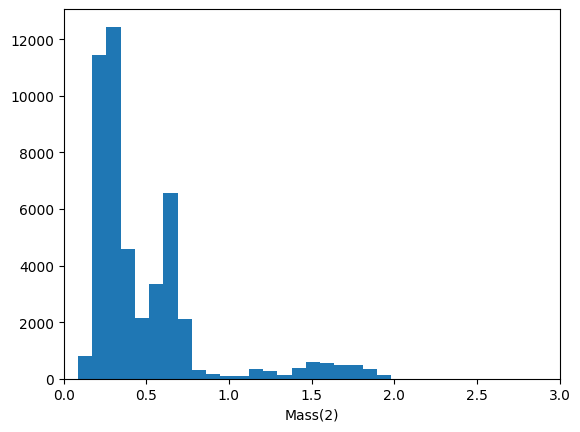

In [7]:
plt.hist(mass_2_merged, bins = np.linspace(0, 2.5, 30))
plt.xlim(0,3)
plt.xlabel("Mass(2)")

In [29]:
sep_all = DCOs_NSNS["SemiMajorAxis@DCO"][()]
sep = sep_all[DCO_mask_NSNS]
sep_merged = sep[condition_mergers]
sep_meter = (sep_merged * u.AU).to(u.m)
sep_solar_radii = (sep_meter.value * u.m).to(u.Rsun)

In [30]:
print(len(mass_1_merged))
print(len(mass_2_merged))
print(len(sep_merged))

50158
50158
50158


Text(0.5, 0, 'Separations (R_sun)')

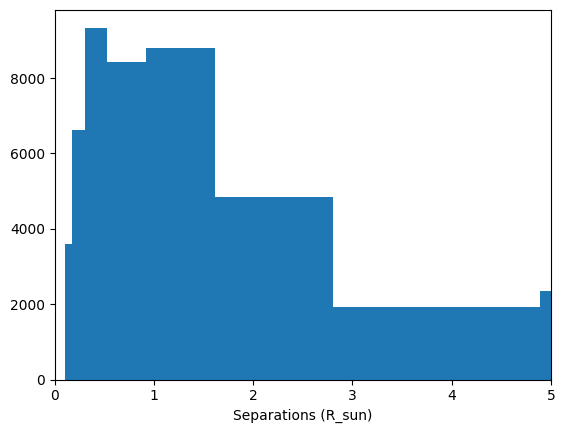

In [31]:
plt.hist(sep_solar_radii.value, bins = np.logspace(-1, 6, 30))
plt.xlim(0,5)
plt.xlabel("Separations (R_sun)")

In [14]:
def tgw(a,e,Mmoremass,Mlessmass,Data,key,parameter):

    """
    Calcualte the coalescence time (inspiral time) in Myrs
    a = semi major axis (expected in AU or Rsun)
    e = eccentricity
    Mmoremass = mass of the more massive compact object (expected in solar masses!)
    Mlessmass = mass of the less massive compact object (expected in solar masses!)
    """

    SYS = Data[key]
    sep_unit = SYS[parameter].attrs['units']
    if sep_unit == b'Rsol':
        a = (a * u.Rsun).to(u.m)

    elif sep_unit == b'AU':
        a = (a * u.AU).to(u.m)      

    Mmoremass = (Mmoremass * u.Msun).to(u.kg)
    Mlessmass = (Mlessmass * u.Msun).to(u.kg)

    tc = ((((5*((a)**4)*(const.c**5))/(256*(const.G**3)*(Mmoremass)*(Mlessmass)*((Mmoremass)+(Mlessmass))))*(1+(0.27*e**10)+(0.33*e**20)+(0.2*e**1000))*(1-(e**2))**(7/2)))*((3.171e-8)*(u.yr/u.s))*((1e-6)*(u.Myr/u.yr))

In [16]:
M1 = np.maximum(DCOs_NSNS["Mass(1)"], DCOs_NSNS["Mass(2)"])
M2 = np.minimum(DCOs_NSNS["Mass(1)"], DCOs_NSNS["Mass(2)"])

ecc = DCOs_NSNS["Eccentricity@DCO"]

In [18]:
tgw(sep_all, ecc, M1, M2, Data_NSNS, 'BSE_Double_Compact_Objects', "SemiMajorAxis@DCO")

TypeError: unsupported operand type(s) for ** or pow(): 'Dataset' and 'int'

In [21]:
a = sep_all[0]
a = (a * u.AU).to(u.m)
e = ecc[0]
Mmoremass = M1[0]
Mlessmass = M2[0]
Mmoremass = (Mmoremass * u.Msun).to(u.kg)
Mlessmass = (Mlessmass * u.Msun).to(u.kg)

tc = ((((5*((a)**4)*(const.c**5))/(256*(const.G**3)*(Mmoremass)*(Mlessmass)*((Mmoremass)+(Mlessmass))))*(1+(0.27*e**10)+(0.33*e**20)+(0.2*e**1000))*(1-(e**2))**(7/2)))*((3.171e-8)*(u.yr/u.s))*((1e-6)*(u.Myr/u.yr))

In [22]:
tc

<Quantity 4.02469455e+15 Myr>